In [7]:
import tensorflow as tf
import os

In [8]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [9]:
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [10]:
pip install filetype

Note: you may need to restart the kernel to use updated packages.


In [11]:
import cv2
import filetype

In [12]:

data_dir = 'data' 

In [13]:
image_exts = ['jpeg','jpg', 'bmp', 'png']


In [66]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

Issue with image data\happy\05-12-21-happy-people.jpg
Issue with image data\happy\07-120104-happy_people_are_not_nice_people.jpg
Issue with image data\happy\1-2.jpg
Issue with image data\happy\1000_F_42220133_toAU6USGY9jVr2XJFLssfG00cSYIJ173.jpg
Issue with image data\happy\11-Habits-of-Truly-Happy-People.jpg
Issue with image data\happy\154006829.jpg
Issue with image data\happy\170404-happy-workers-feature.jpg
Issue with image data\happy\1902539.jpg
Issue with image data\happy\1902540.jpg
Issue with image data\happy\1902587.jpg
Issue with image data\happy\1920px-face-smile.svg_.png.jpg
Issue with image data\happy\1HEoLBLidT2u4mhJ0oiDgig.png
Issue with image data\happy\227-2271622_happy-people-business-team-celebrating-png.png
Issue with image data\happy\60632274._UY200_.jpg
Issue with image data\happy\7-Habits-of-Happy-People-image.jpeg
Issue with image data\happy\7-principles-of-successful-and-happy-people.png
Issue with image data\happy\7Y57w0983emdERAoQylUHIGkoEk1cIFvPkXDbeA2lVA.jpg


In [67]:

import numpy as np
from matplotlib import pyplot as plt

In [68]:
data = tf.keras.utils.image_dataset_from_directory('data')


Found 305 files belonging to 2 classes.


In [69]:
data_iterator = data.as_numpy_iterator()


In [70]:
batch = data_iterator.next()


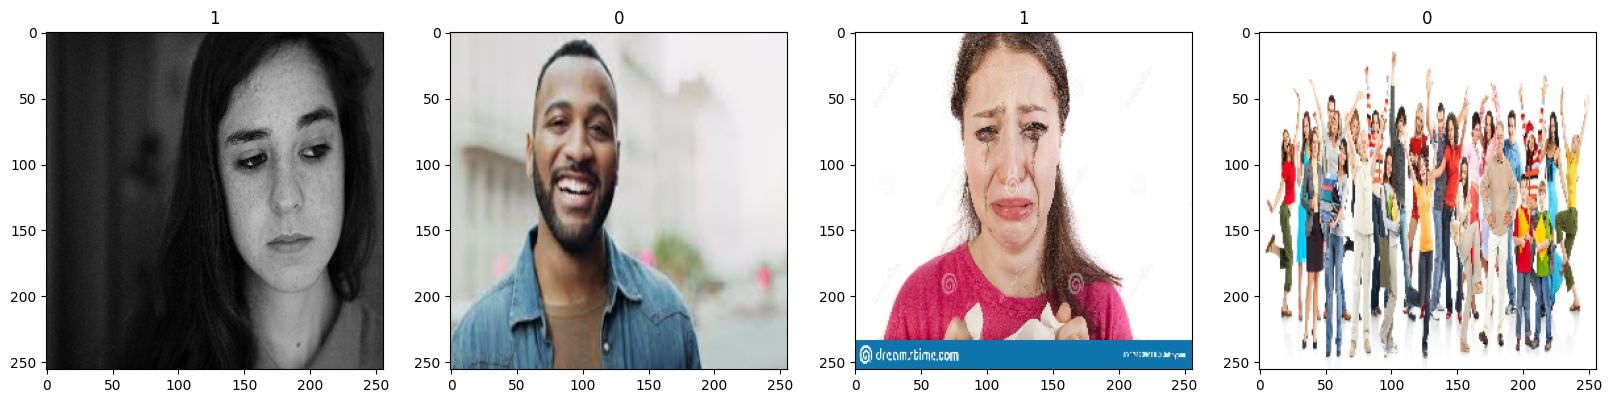

In [71]:

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [72]:
data = data.map(lambda x,y: (x/255, y))


In [73]:
data.as_numpy_iterator().next()


(array([[[[0.77254903, 0.76862746, 0.5930607 ],
          [0.77254903, 0.76862746, 0.5894455 ],
          [0.7764706 , 0.77254903, 0.58431375],
          ...,
          [0.64705884, 0.6627451 , 0.53333336],
          [0.6386106 , 0.6542969 , 0.5248851 ],
          [0.6392157 , 0.654902  , 0.5254902 ]],
 
         [[0.77254903, 0.76862746, 0.59576017],
          [0.77254903, 0.76862746, 0.5894455 ],
          [0.7764706 , 0.77254903, 0.58431375],
          ...,
          [0.64705884, 0.6627451 , 0.53333336],
          [0.6386106 , 0.6542969 , 0.5248851 ],
          [0.6392157 , 0.654902  , 0.5254902 ]],
 
         [[0.77254903, 0.76862746, 0.595548  ],
          [0.77254903, 0.76862746, 0.59491247],
          [0.7764706 , 0.77254903, 0.5902858 ],
          ...,
          [0.64705884, 0.6627451 , 0.53333336],
          [0.6386106 , 0.6542969 , 0.5248851 ],
          [0.6392157 , 0.654902  , 0.5254902 ]],
 
         ...,
 
         [[0.67300093, 0.6932138 , 0.5420803 ],
          [0.67119

In [74]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [75]:
train_size


7

In [76]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [77]:
train


<TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [79]:
model = Sequential()


In [80]:
from tensorflow.keras.layers import Input

In [81]:
model = Sequential([
    Input(shape=(256, 256, 3)),
    Conv2D(16, (3,3), 1, activation='relu'),
    MaxPooling2D(),
    Conv2D(32, (3,3), 1, activation='relu'),
    MaxPooling2D(),
    Conv2D(16, (3,3), 1, activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [82]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])


In [83]:
model.summary()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 127, 127, 16)     0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 62, 62, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 60, 60, 16)        4624      
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 30, 30, 16)      

In [84]:
logdir='logs'


In [85]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)


In [86]:
tf.keras.backend.set_floatx('float32')

In [87]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])


Epoch 1/20
7/7 [==============================] - 3s 215ms/step - loss: 0.9589 - accuracy: 0.4911 - val_loss: 0.6523 - val_accuracy: 0.5625
Epoch 2/20
7/7 [==============================] - 2s 214ms/step - loss: 0.6637 - accuracy: 0.5089 - val_loss: 0.6238 - val_accuracy: 0.5625
Epoch 3/20
7/7 [==============================] - 2s 210ms/step - loss: 0.5857 - accuracy: 0.6875 - val_loss: 0.5014 - val_accuracy: 0.7812
Epoch 4/20
7/7 [==============================] - 2s 214ms/step - loss: 0.5759 - accuracy: 0.7188 - val_loss: 0.4125 - val_accuracy: 0.8281
Epoch 5/20
7/7 [==============================] - 2s 206ms/step - loss: 0.5007 - accuracy: 0.7589 - val_loss: 0.4754 - val_accuracy: 0.8594
Epoch 6/20
7/7 [==============================] - 2s 212ms/step - loss: 0.4540 - accuracy: 0.7857 - val_loss: 0.3989 - val_accuracy: 0.8438
Epoch 7/20
7/7 [==============================] - 2s 214ms/step - loss: 0.3763 - accuracy: 0.8304 - val_loss: 0.2779 - val_accuracy: 0.8750
Epoch 8/20
7/7 [====

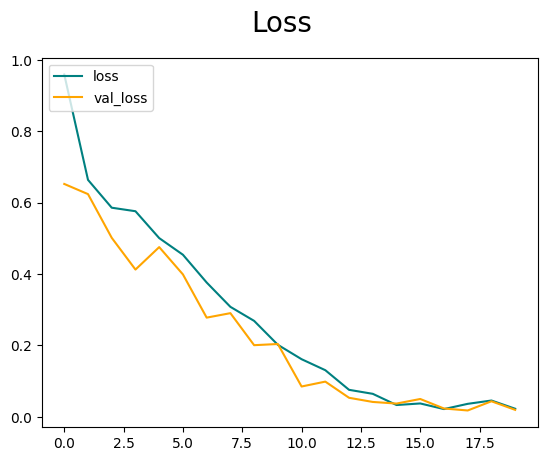

In [88]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

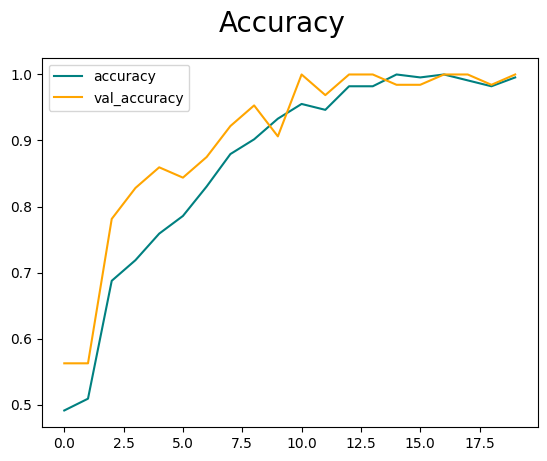

In [89]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [90]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [91]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [92]:

for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 [==============================] - 0s 95ms/step


In [93]:
print(pre.result(), re.result(), acc.result())


tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [94]:
import cv2


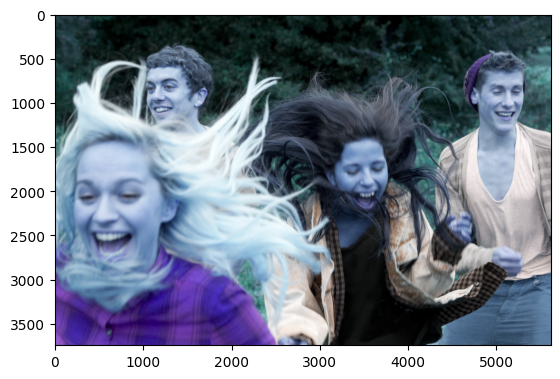

In [95]:
img = cv2.imread('154006829.jpg')
plt.imshow(img)
plt.show()

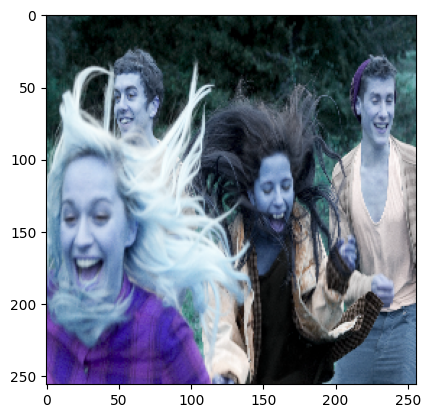

In [96]:

resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [97]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 0s 18ms/step


In [98]:
yhat


array([[0.22998624]], dtype=float32)

In [99]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


In [100]:
from tensorflow.keras.models import load_model


In [103]:
model.save(os.path.join('models','imageclassifier.h5'))


In [105]:
import os
print(os.getcwd())

D:\code\image_classifier


In [109]:
new_model = load_model(r'D:\code\image_classifier\models\imageclassifier.h5')

In [111]:
new_model.predict(np.expand_dims(resize/255, 0))


1/1 [==============================] - 0s 79ms/step


array([[0.22998624]], dtype=float32)